In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

clinical_gex = pd.read_csv('../dataset/created/clinical_gex/clinical_gex_rfe_without_bor.csv')
clinical_gex

,Unnamed: 0,m_stage_prep__M_stage,remainder__age,TIAM1,CYLD,NRAS,GADD45B,SKI,DIABLO,ATR,...,CA2,SLC31A1,EIF3F,ERICH1,SMPD1,ZNF229,TRAF3,TSPAN10,SYN1,pfs_label
0,0,1.0,26.0,4.740826,5.456537,5.915934,5.661323,5.540349,7.943598,4.342311,...,5.566860,6.351247,8.136391,6.160624,5.838381,4.181424,5.023265,7.142719,4.493141,0
1,1,0.0,58.0,4.617150,5.236413,5.586915,5.635799,5.608741,7.889908,4.468162,...,5.535641,7.146814,9.068658,6.028205,6.777170,4.069181,4.805716,7.400251,4.486218,2
2,2,0.0,45.0,4.881503,6.313049,5.626622,5.767666,5.260630,7.848552,4.603605,...,5.664685,6.426968,8.281834,6.197951,5.752238,4.103541,5.275061,7.052908,4.486560,2
3,3,2.0,48.0,4.562268,5.378751,5.671719,5.877948,5.367287,7.446819,4.209637,...,6.050421,6.616535,8.383561,5.991895,5.822169,4.001085,4.908581,7.135489,4.485692,0
4,4,2.0,33.0,4.667443,5.126189,6.028275,5.652797,5.359803,7.952144,4.554924,...,5.514046,6.569313,8.846730,6.248220,6.008011,4.241059,4.355761,7.201527,4.473697,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,120,2.0,62.0,4.904966,5.319405,5.151813,6.041600,4.961385,7.800308,4.398480,...,5.634744,6.101056,8.347044,5.838393,6.969404,4.055136,4.822670,6.140929,4.532004,2
121,121,2.0,49.0,4.707454,5.534735,6.571055,5.409275,6.110449,7.921539,4.590091,...,6.083548,6.660309,8.455387,6.590784,5.470886,4.055136,4.868126,6.716541,4.485743,0
122,122,2.0,68.0,4.726721,5.883901,6.288109,6.086616,5.851436,7.492301,4.529005,...,6.253337,6.984539,8.328132,6.357252,5.766866,4.055136,5.332030,6.920163,4.497211,0
123,123,2.0,72.0,4.592521,5.547222,5.826639,5.755333,5.985148,7.753804,4.540538,...,5.914217,7.313511,8.434705,6.269563,6.104890,4.055136,5.097706,8.827673,4.504805,0


In [78]:
y = clinical_gex['pfs_label']
x = clinical_gex.drop(['pfs_label', 'Unnamed: 0'], axis=1)
x.head()

,m_stage_prep__M_stage,remainder__age,TIAM1,CYLD,NRAS,GADD45B,SKI,DIABLO,ATR,PSMD10,...,PERP,CA2,SLC31A1,EIF3F,ERICH1,SMPD1,ZNF229,TRAF3,TSPAN10,SYN1
0,1.0,26.0,4.740826,5.456537,5.915934,5.661323,5.540349,7.943598,4.342311,7.227893,...,6.450864,5.566860,6.351247,8.136391,6.160624,5.838381,4.181424,5.023265,7.142719,4.493141
1,0.0,58.0,4.617150,5.236413,5.586915,5.635799,5.608741,7.889908,4.468162,7.150913,...,6.397098,5.535641,7.146814,9.068658,6.028205,6.777170,4.069181,4.805716,7.400251,4.486218
2,0.0,45.0,4.881503,6.313049,5.626622,5.767666,5.260630,7.848552,4.603605,7.050374,...,6.509725,5.664685,6.426968,8.281834,6.197951,5.752238,4.103541,5.275061,7.052908,4.486560
3,2.0,48.0,4.562268,5.378751,5.671719,5.877948,5.367287,7.446819,4.209637,7.096730,...,6.448743,6.050421,6.616535,8.383561,5.991895,5.822169,4.001085,4.908581,7.135489,4.485692
4,2.0,33.0,4.667443,5.126189,6.028275,5.652797,5.359803,7.952144,4.554924,7.197295,...,6.272253,5.514046,6.569313,8.846730,6.248220,6.008011,4.241059,4.355761,7.201527,4.473697


In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif, RFECV
from xgboost import XGBClassifier

clf = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_split = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=clf, cv=cv_split, scoring='f1_macro', n_jobs=-1, step=1)

xgboost_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=100,      # keep small — 125 samples
    max_depth=3,           # shallow trees — prevents overfit
    learning_rate=0.05,
    subsample=0.8,         # row sampling
    colsample_bytree=0.8,  # feature sampling
    reg_alpha=1.0,         # L1 regulariazation
    reg_lambda=1.0,        # L2 regularization
    eval_metric='mlogloss',
    random_state=42
)

# feat_select_pipe = Pipeline([
#     ('variance', VarianceThreshold(threshold=0.90)),
#     # ('selectk', SelectKBest(mutual_info_classif, k=20)),
#     ('rfecv', rfecv),
#     ('classifier', xgboost_clf)
# ])

results = cross_validate(
    xgboost_clf, x, y,
    cv=cv_split,
    scoring=['roc_auc_ovo', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

print(f"ROC-AUC (OVO)   : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Macro F1        : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")


ROC-AUC (OVO)   : 0.836 ± 0.049
Macro F1        : 0.651 ± 0.112


                     precision    recall  f1-score   support

  Short resp (n=66)       0.69      0.89      0.78        66
Intermediate (n=27)       0.81      0.48      0.60        27
   Long resp (n=32)       0.70      0.50      0.58        32

           accuracy                           0.70       125
          macro avg       0.73      0.63      0.65       125
       weighted avg       0.72      0.70      0.69       125



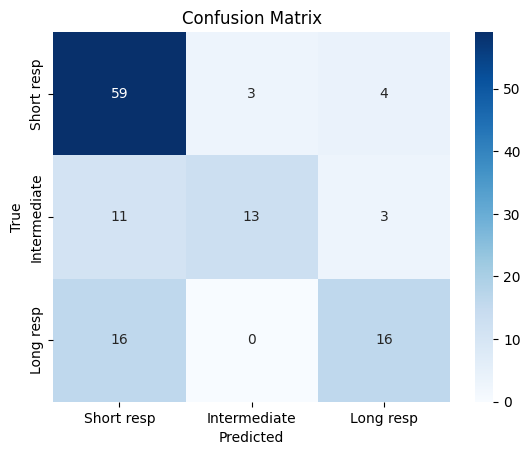

In [80]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = cross_val_predict(xgboost_clf, x, y, cv=cv_split, n_jobs=-1)
print(classification_report(y, y_pred, 
      target_names=['Short resp (n=66)', 
                    'Intermediate (n=27)', 
                    'Long resp (n=32)']))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Short resp','Intermediate','Long resp'],
            yticklabels=['Short resp','Intermediate','Long resp'],
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [81]:
# xgboost_clf = XGBClassifier(
#     objective='multi:softprob',
#     num_class=3,
#     n_estimators=100,      # keep small — 125 samples
#     max_depth=3,           # shallow trees — prevents overfit
#     learning_rate=0.05,
#     subsample=0.8,         # row sampling
#     colsample_bytree=0.8,  # feature sampling
#     reg_alpha=1.0,         # L1 regulariazation
#     reg_lambda=1.0,        # L2 regularization
#     eval_metric='mlogloss',
#     random_state=42
# )

In [82]:
# import xgboost as xgb

# x_rfe_df = pd.DataFrame(x_rfe, columns=rfecv.get_feature_names_out())
# xgboost_clf.fit(x_rfe_df, y)

# fig, ax = plt.subplots(figsize=(16, 12))
# xgb.plot_importance(xgboost_clf, ax=ax)
# plt.tight_layout()
# plt.show()